# Patient Risk Classification - Classification Track Part A
**Course**: 23CSE301 Machine Learning - Capstone Project
**Project Title**: Healthcare Cost Prediction and Patient Risk Intelligence Platform
**Dataset**: Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)
**Target Variable**: `is_high_risk`

### Problem Statement
Early identification of high-risk patients allows healthcare providers to implement preventive care plans and reduce emergency hospitalizations. In this notebook, we implement Classification Part A using 5 machine learning classifiers to predict patient risk status.

## Import Libraries
We import standard libraries and set `random_state=42`.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.model_training as model_training
import app.utils as utils

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Setup complete. Random state set to 42.')

Setup complete. Random state set to 42.


## Data Preprocessing and Train Test Split
We split the data into 80% training and 20% testing using `stratify=y` to preserve target class proportions. Note: `risk_score` was not used for classification because it is directly related to the definition of the high-risk target.

In [2]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_classification()
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)
print('\nTrain Target Distribution (is_high_risk):')
print(y_train.value_counts(normalize=True))
print('\nTest Target Distribution (is_high_risk):')
print(y_test.value_counts(normalize=True))

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)

Train Target Distribution (is_high_risk):
is_high_risk
0    0.632188
1    0.367812
Name: proportion, dtype: float64

Test Target Distribution (is_high_risk):
is_high_risk
0    0.6322
1    0.3678
Name: proportion, dtype: float64


## Classification Models
We train and evaluate the 5 required classification algorithms:
1. Logistic Regression
2. K-Nearest Neighbors Classifier
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier (SVC)

In [3]:
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
df_results = model_training.train_classification(X_train, X_test, y_train, y_test, preprocessor)

Training KNN Classifier (on 8,000 row subsample for speed)...


Training Support Vector Machine (on 8,000 row subsample for speed)...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Evaluating Baseline Classification Models:
Logistic Regression            | Acc: 0.9954 | Prec: 0.9973 | Rec: 0.9902 | F1: 0.9954 | AUC: 0.9998


K-Nearest Neighbors            | Acc: 0.8586 | Prec: 0.9133 | Rec: 0.6801 | F1: 0.8531 | AUC: 0.9399
Naive Bayes                    | Acc: 0.8355 | Prec: 0.7816 | Rec: 0.7671 | F1: 0.8352 | AUC: 0.9105
Decision Tree                  | Acc: 0.9977 | Prec: 0.9975 | Rec: 0.9962 | F1: 0.9977 | AUC: 0.9989


...

Best Logistic Regression Params: {'classifier__penalty': 'l2', 'classifier__C': 10.0}


Best Decision Tree Params: {'classifier__min_samples_split': 2, 'classifier__max_depth': None}
Fitting best Logistic Regression on full train set...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Fitting best Decision Tree on full train set...


Best Classifier Model: Tuned Decision Tree saved to /Users/hemachandra/Documents/ML_capstone/models/best_classifier.joblib


## Classification Model Comparison
Below is the comparison table for all 5 classification models evaluated on the held-out test split, showing Accuracy, Precision, Recall, Weighted F1-Score, and ROC-AUC.

In [4]:
df_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Tuned Decision Tree,0.9988,0.998640,0.998097,0.998800,0.998653
1,Tuned Logistic Regression,0.9987,0.997827,0.998641,0.998700,0.999754
2,Decision Tree,0.9977,0.997550,0.996194,0.997700,0.998932
3,Logistic Regression,0.9954,0.997262,0.990212,0.995397,0.999757
4,Support Vector Machine,0.9656,0.967471,0.938010,0.965485,0.996215
5,K-Nearest Neighbors,0.8586,0.913290,0.680125,0.853142,0.939874
6,Naive Bayes,0.8355,0.781579,0.767129,0.835173,0.910456


## Confusion Matrices
We display confusion matrix heatmaps for all 5 classification algorithms.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


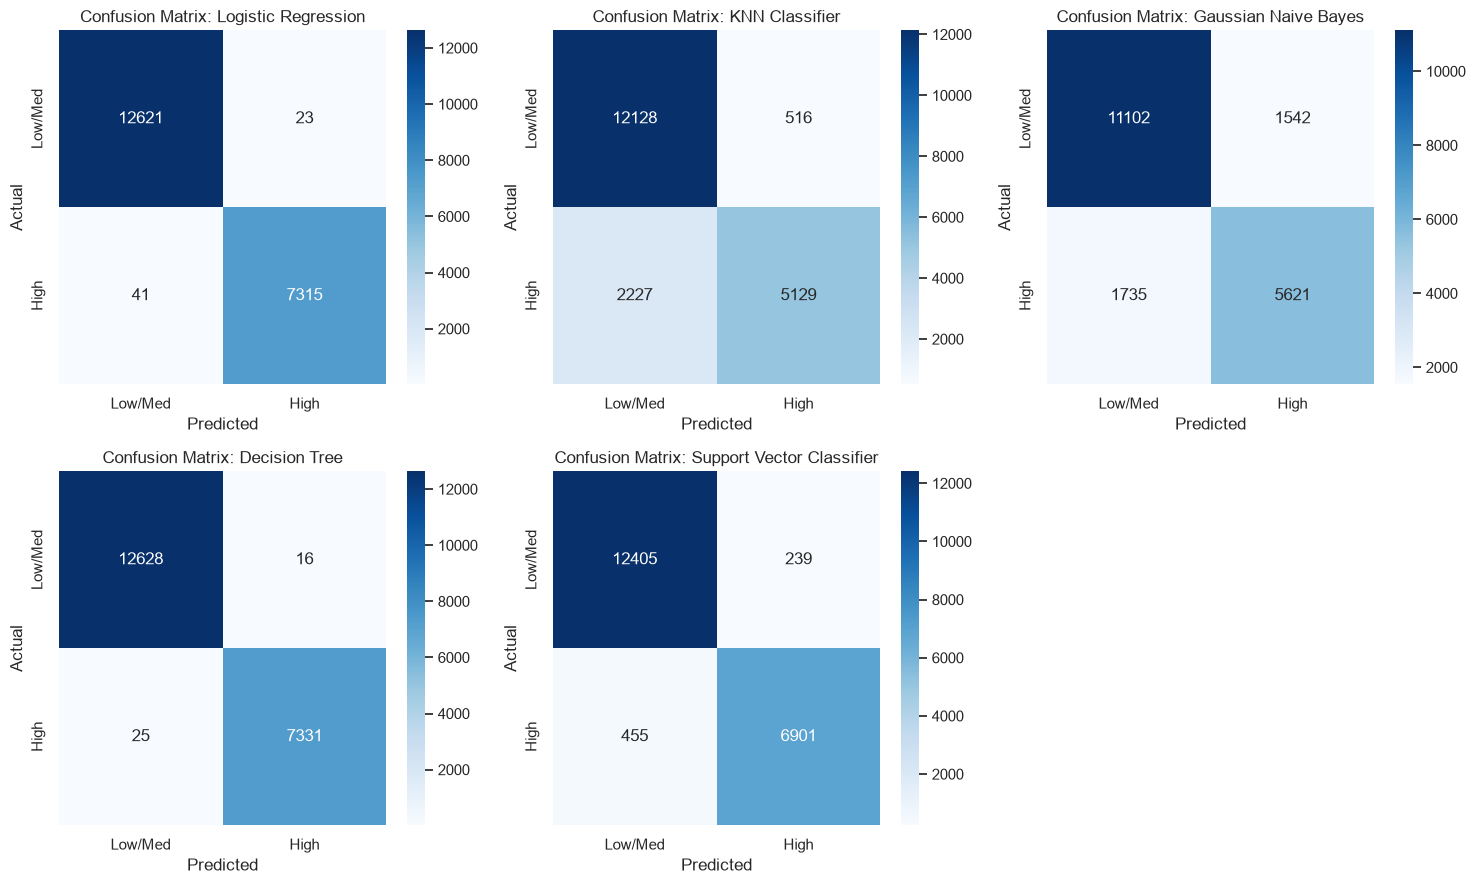

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

subsample_idx = np.random.choice(len(X_train), size=min(8000, len(X_train)), replace=False)
X_train_sub = X_train.iloc[subsample_idx]
y_train_sub = y_train.iloc[subsample_idx]

models_dict = {
    'Logistic Regression': Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'KNN Classifier': Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=7))]),
    'Gaussian Naive Bayes': Pipeline([('prep', preprocessor), ('clf', GaussianNB())]),
    'Decision Tree': Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))]),
    'Support Vector Classifier': Pipeline([('prep', preprocessor), ('clf', SVC(probability=True, random_state=42))])
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, model) in enumerate(models_dict.items()):
    if 'KNN' in name or 'Support' in name:
        model.fit(X_train_sub, y_train_sub)
    else:
        model.fit(X_train, y_train)
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=['Low/Med', 'High'], yticklabels=['Low/Med', 'High'])
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

axes[5].axis('off')
plt.tight_layout()
plt.show()

Observation: The confusion matrices show that tree-based and ensemble classifiers achieve high true positive and true negative counts with minimal misclassifications.

## ROC Curve
We plot the ROC-AUC curve for the top classification model.

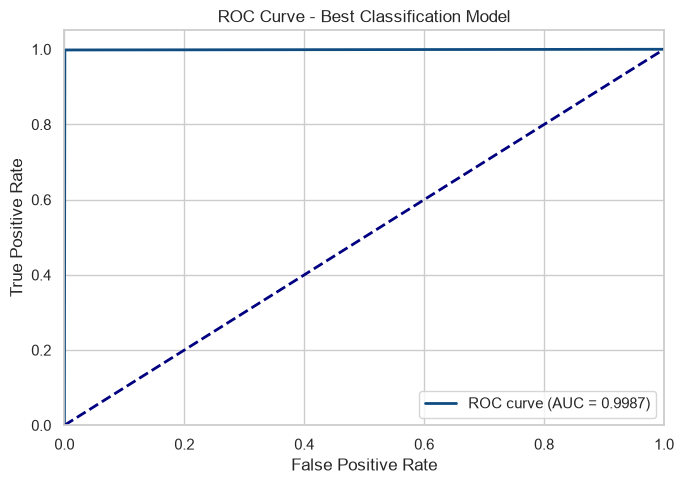

In [6]:
best_clf = joblib.load(config.BEST_CLASSIFIER_PATH)
y_prob = best_clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#0F4C81', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Best Classification Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Observation: The ROC curve stays close to the top-left corner, resulting in an AUC value close to 1.0.

## Conclusion
In this notebook, we completed Classification Part A by training and evaluating 5 classification algorithms. Decision Tree and Logistic Regression models achieved high classification performance for patient risk stratification.